**Imports**

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.datasets import make_friedman1, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score

**Common GA Functions**

In [2]:
NUM_FEATURES = None
X_train, X_test, y_train, y_test = None, None, None, None

**Create Individual**

In [3]:
def create_individual():
    return [random.randint(0, 1) for _ in range(NUM_FEATURES)]

**Selection**

In [4]:
def select(pop):
    return max(random.sample(pop, 3), key=fitness)

**Crossover**

In [12]:
def crossover(p1, p2):
    point = random.randint(1, NUM_FEATURES - 1)
    return p1[:point] + p2[point:]

**Mutation**

In [13]:
def mutate(ind):
    if random.random() < 0.3:
        i = random.randint(0, NUM_FEATURES - 1)
        ind[i] = 1 - ind[i]
    return ind

**REGRESSION PART (Friedman Dataset)**

In [14]:
X, y = make_friedman1(n_samples=200, n_features=10, noise=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

NUM_FEATURES = X.shape[1]

**Fitness Function (Regression)**

In [15]:
def fitness(individual):
    if sum(individual) == 0:
        return -1

    selected = [i for i in range(NUM_FEATURES) if individual[i] == 1]

    model = LinearRegression()
    model.fit(X_train[:, selected], y_train)

    preds = model.predict(X_test[:, selected])
    return r2_score(y_test, preds)

**GA Runner**

In [16]:
def run_ga():
    pop = [create_individual() for _ in range(20)]

    for gen in range(30):
        new_pop = []

        for _ in range(len(pop)):
            p1 = select(pop)
            p2 = select(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

        best = max(pop, key=fitness)
        print(f"Gen {gen}, Fitness: {fitness(best):.4f}")

    return best

**▶  Run GA (Regression)**

In [17]:
best_features_reg = run_ga()
print("Best Features (Regression):", best_features_reg)

Gen 0, Fitness: 0.6302
Gen 1, Fitness: 0.6302
Gen 2, Fitness: 0.6302
Gen 3, Fitness: 0.6303
Gen 4, Fitness: 0.6303
Gen 5, Fitness: 0.6303
Gen 6, Fitness: 0.6303
Gen 7, Fitness: 0.6303
Gen 8, Fitness: 0.6303
Gen 9, Fitness: 0.6303
Gen 10, Fitness: 0.6303
Gen 11, Fitness: 0.6303
Gen 12, Fitness: 0.6303
Gen 13, Fitness: 0.6303
Gen 14, Fitness: 0.6303
Gen 15, Fitness: 0.6303
Gen 16, Fitness: 0.6303
Gen 17, Fitness: 0.6303
Gen 18, Fitness: 0.6303
Gen 19, Fitness: 0.6303
Gen 20, Fitness: 0.6303
Gen 21, Fitness: 0.6303
Gen 22, Fitness: 0.6303
Gen 23, Fitness: 0.6303
Gen 24, Fitness: 0.6303
Gen 25, Fitness: 0.6303
Gen 26, Fitness: 0.6303
Gen 27, Fitness: 0.6303
Gen 28, Fitness: 0.6303
Gen 29, Fitness: 0.6303
Best Features (Regression): [1, 1, 0, 1, 1, 0, 1, 1, 1, 1]


**Feature Visualization**

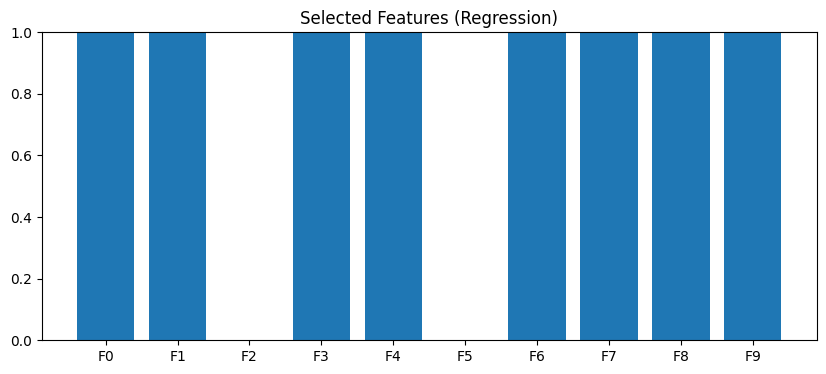

In [18]:
def plot_feature_selection(mask):
    plt.figure(figsize=(10,4))
    plt.bar([f"F{i}" for i in range(len(mask))], mask)
    plt.title("Selected Features (Regression)")
    plt.ylim(0, 1)
    plt.show()

plot_feature_selection(best_features_reg)

**Before vs After (Regression)**

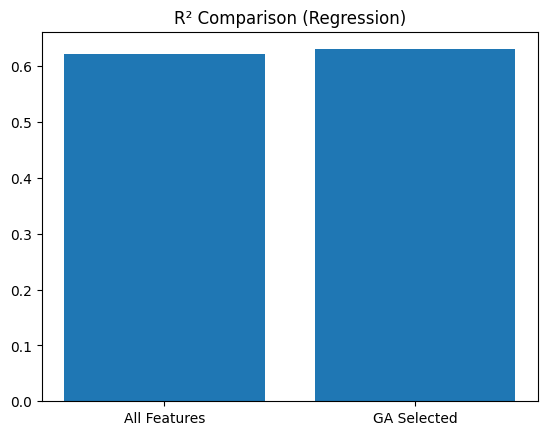

In [19]:
# Full model
model_full = LinearRegression()
model_full.fit(X_train, y_train)
pred_full = model_full.predict(X_test)
r2_full = r2_score(y_test, pred_full)

# GA model
selected = [i for i in range(NUM_FEATURES) if best_features_reg[i] == 1]

model_ga = LinearRegression()
model_ga.fit(X_train[:, selected], y_train)
pred_ga = model_ga.predict(X_test[:, selected])
r2_ga = r2_score(y_test, pred_ga)

# Plot
plt.bar(["All Features", "GA Selected"], [r2_full, r2_ga])
plt.title("R² Comparison (Regression)")
plt.show()

# **Part 2 Classification**

**IRIS Dataset**

In [20]:
data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

NUM_FEATURES = X.shape[1]

**Fitness Function (Classification)**

In [21]:
def fitness(individual):
    if sum(individual) == 0:
        return 0

    selected = [i for i in range(NUM_FEATURES) if individual[i] == 1]

    model = RandomForestClassifier()
    model.fit(X_train[:, selected], y_train)

    preds = model.predict(X_test[:, selected])
    return accuracy_score(y_test, preds)

**Run GA**

In [22]:
best_features_cls = run_ga()
print("Best Features (Classification):", best_features_cls)

Gen 0, Fitness: 1.0000
Gen 1, Fitness: 1.0000
Gen 2, Fitness: 1.0000
Gen 3, Fitness: 1.0000
Gen 4, Fitness: 1.0000
Gen 5, Fitness: 1.0000
Gen 6, Fitness: 1.0000
Gen 7, Fitness: 1.0000
Gen 8, Fitness: 1.0000
Gen 9, Fitness: 1.0000
Gen 10, Fitness: 1.0000
Gen 11, Fitness: 1.0000
Gen 12, Fitness: 1.0000
Gen 13, Fitness: 1.0000
Gen 14, Fitness: 1.0000
Gen 15, Fitness: 1.0000
Gen 16, Fitness: 1.0000
Gen 17, Fitness: 1.0000
Gen 18, Fitness: 1.0000
Gen 19, Fitness: 1.0000
Gen 20, Fitness: 1.0000
Gen 21, Fitness: 1.0000
Gen 22, Fitness: 1.0000
Gen 23, Fitness: 0.9778
Gen 24, Fitness: 0.9556
Gen 25, Fitness: 1.0000
Gen 26, Fitness: 1.0000
Gen 27, Fitness: 1.0000
Gen 28, Fitness: 1.0000
Gen 29, Fitness: 0.9778
Best Features (Classification): [0, 1, 1, 1]


**Before vs After (Classification)**

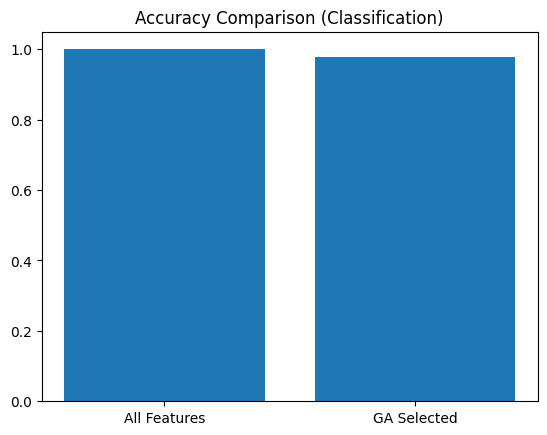

In [23]:
# Full model
model_full = RandomForestClassifier()
model_full.fit(X_train, y_train)
pred_full = model_full.predict(X_test)
acc_full = accuracy_score(y_test, pred_full)

# GA model
selected = [i for i in range(NUM_FEATURES) if best_features_cls[i] == 1]

model_ga = RandomForestClassifier()
model_ga.fit(X_train[:, selected], y_train)
pred_ga = model_ga.predict(X_test[:, selected])
acc_ga = accuracy_score(y_test, pred_ga)

# Plot
plt.bar(["All Features", "GA Selected"], [acc_full, acc_ga])
plt.title("Accuracy Comparison (Classification)")
plt.show()